# Data Analysis

Log

- 19/01/2025: Init

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [2]:
fpath_records = './data/records.json'
def get_df() -> pd.DataFrame:
    return pd.read_json(fpath_records)

In [3]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

df.shape:  (160, 6)
df ∑nRecords:  1120
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,Iso18013DriversLicenseCredential-sd-002-att,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,Iso18013DriversLicenseCredential-sd-002-att,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
157,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,Iso18013DriversLicenseCredential-sd-016-att,9
158,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,Iso18013DriversLicenseCredential-sd-016-att,9
159,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,9


a.shape:  (1120, 6)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0


b.shape:  (1120, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,517.604458,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,573.488542,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,573.900542,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [4]:
c = a[['iteration','implementationClass', 'credentialSetupKey']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (1120, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,START_SIGN_VC,mark,517.604458
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,END_SIGN_VC,mark,573.488542
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,START_VERIFY_VC,mark,573.900542


Filter: only keep `mark` entries.

In [5]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (1120, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,START_SIGN_VC,mark,517.604458
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,END_SIGN_VC,mark,573.488542
0,0,Implementation_BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,START_VERIFY_VC,mark,573.900542


Some final preprocessing.

In [6]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (1120, 6)


,iteration,credentialSetupKey,startTime,implementation,step,stepType
0,0,Iso18013DriversLicenseCredential-sd-002-att,517.604458,BbsBlsSignature2020,SIGN_VC,START
0,0,Iso18013DriversLicenseCredential-sd-002-att,573.488542,BbsBlsSignature2020,SIGN_VC,END
0,0,Iso18013DriversLicenseCredential-sd-002-att,573.900542,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [7]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

**Background** 

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [8]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (1120, 1)


startTime
implementation      credentialSetupKey                          iteration step      stepType            
BbsBlsSignature2020 Iso18013DriversLicenseCredential-sd-002-att 0         SIGN_VC   START     517.604458
                                                                                    END       573.488542
                                                                          VERIFY_VC START     573.900542

In [9]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')
print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (560, 1)


delta
implementation      credentialSetupKey                          iteration step                      
BbsBlsSignature2020 Iso18013DriversLicenseCredential-sd-002-att 0         DERIVE          108.919417
                                                                          SIGN_VC          55.884084
                                                                          VERIFY_DERIVED   43.968708

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [10]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation           credentialSetupKey                          step                         
BbsBlsSignature2020      Iso18013DriversLicenseCredential-sd-002-att DERIVE           99.855996   
                                                                     SIGN_VC          31.101092   
                                                                     VERIFY_DERIVED   41.545288   
                                                                     VERIFY_VC        55.750625   
                         Iso18013DriversLicenseCredential-sd-004-att DERIVE           97.691663   
                                                                     SIGN_VC          28.586621   
                                                                     VERIFY_DERIVED   41.280862   
                                                                     VERIFY_VC        53.799483   
                         Iso18013DriversLicenseCredential-sd-008-att DERIVE           96.585921   
                                                                     SIGN_VC          28.245954   
                                                                     VERIFY_DERIVED   41.212867   
                                                                     VERIFY_VC        54.297379   
                         Iso18013DriversLicenseCredential-sd-016-att DERIVE           94.916638   
                                                                     SIGN_VC          28.308900   
                                                                     VERIFY_DERIVED   41.077104   
                                                                     VERIFY_VC        53.832987   
BbsTermwiseSignature2023 Iso18013DriversLicenseCredential-sd-002-att DERIVE          240.162742   
                                                                     SIGN_VC         107.231458   
                                                                     VERIFY_DERIVED  126.075191   
                                                                     VERIFY_VC       111.002892   
                         Iso18013DriversLicenseCredential-sd-004-att DERIVE          236.265208   
                                                                     SIGN_VC          93.995883   
                                                                     VERIFY_DERIVED  127.035400   
                                                                     VERIFY_VC       105.444771   
                         Iso18013DriversLicenseCredential-sd-008-att DERIVE          235.022788   
                                                                     SIGN_VC          93.795117   
                                                                     VERIFY_DERIVED  129.006913   
                                                                     VERIFY_VC       107.243779   
                         Iso18013DriversLicenseCredential-sd-016-att DERIVE          233.106196   
                                                                     SIGN_VC          93.848325   
                                                                     VERIFY_DERIVED  128.583967   
                                                                     VERIFY_VC       107.670046   
EcdsaSd2023Cryptosuite   Iso18013DriversLicenseCredential-sd-002-att DERIVE            5.337904   
                                                                     SIGN_VC           5.567892   
                                                                     VERIFY_DERIVED    3.379317   
                                                                     VERIFY_VC         3.880966   
                         Iso18013DriversLicenseCredential-sd-004-att DERIVE            4.935896   
                                                                     SIGN_VC           5.283892   
                                                                     VERIFY_DERIVED    3.279012   
                                

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [11]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['implementation','credentialSetupKey',],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  31.10   
VERIFY_VC                                                55.75   
DERIVE                                                   99.86   
VERIFY_DERIVED                                           41.55   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  28.59   
VERIFY_VC                                                53.80   
DERIVE                                                   97.69   
VERIFY_DERIVED                                           41.28   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  28.25   
VERIFY_VC                                                54.30   
DERIVE                                                   96.59   
VERIFY_DERIVED                                           41.21   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  28.31   
VERIFY_VC                                                53.83   
DERIVE                                                   94.92   
VERIFY_DERIVED                                           41.08   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                 107.23   
VERIFY_VC                                               111.00   
DERIVE                                                  240.16   
VERIFY_DERIVED                                          126.08   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  94.00   
VERIFY_VC                                               105.44   
DERIVE                                                  236.27   
VERIFY_DERIVED                                          127.04   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  93.80   
VERIFY_VC                                               107.24   
DERIVE                                                  235.02   
VERIFY_DERIVED                                          129.01   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  93.85   
VERIFY_VC                                               107.67   
DERIVE                                                  233.11   
VERIFY_DERIVED                                          128.58   

implementation                          EcdsaSd2023Cryptosuite  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                   5.57   
VERIFY_VC                       

Plotting (Seaborn)

In [12]:
dfsb = df_delta.reset_index()
print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (560, 5)


,implementation,credentialSetupKey,iteration,step,delta
0,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,DERIVE,108.919417
1,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,SIGN_VC,55.884084
2,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,VERIFY_DERIVED,43.968708


In [13]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


In [14]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)

In [15]:
csk_vc.index

Index(['Iso18013DriversLicenseCredential-sd-002-att',
       'Iso18013DriversLicenseCredential-sd-004-att',
       'Iso18013DriversLicenseCredential-sd-008-att',
       'Iso18013DriversLicenseCredential-sd-016-att'],
      dtype='object')

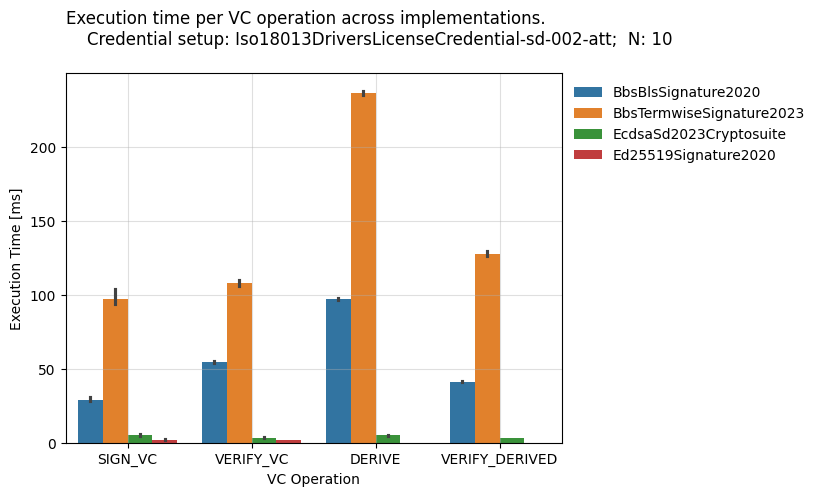

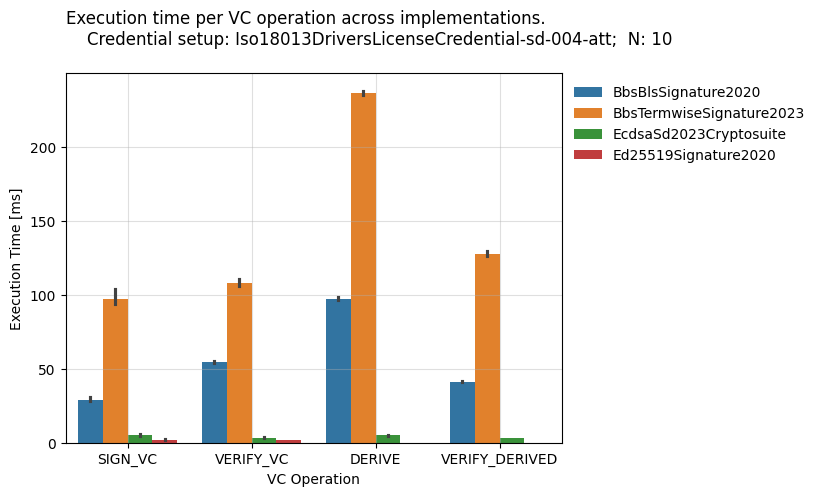

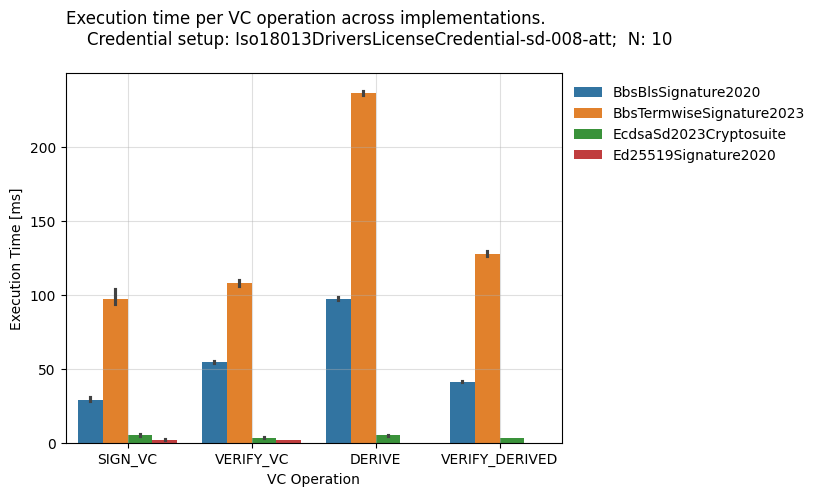

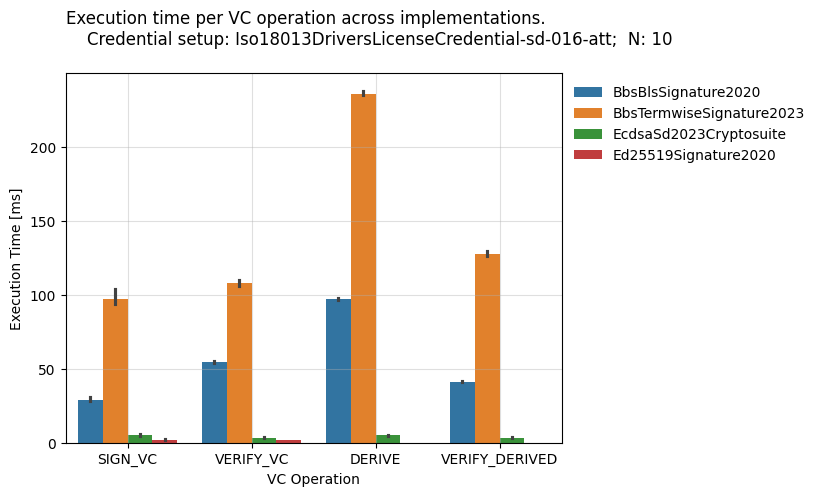

In [16]:
for csk in csk_vc.index:
    N = dfsb.iteration.max() + 1
    
    ax = sns.barplot(
        data = dfsb,
        x = 'step',
        y = 'delta',
        hue = 'implementation',
        order=step_order,
        hue_order=implementation_order
    )
    
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time per VC operation across implementations.
    Credential setup: {csk};  N: {N}
    ''',loc='left')
    ax.set_xlabel('VC Operation')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    plt.show()
    
    

Let's focus on each VC operation separately.

In [17]:
STEPS = ['SIGN_VC', 'VERIFY_VC','DERIVE', 'VERIFY_DERIVED']

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


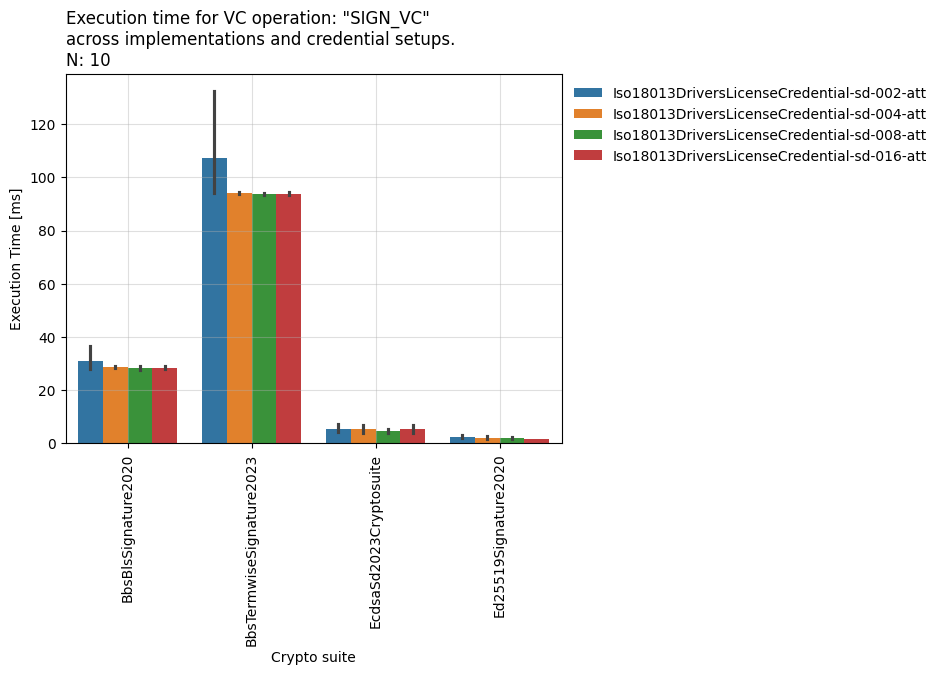

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


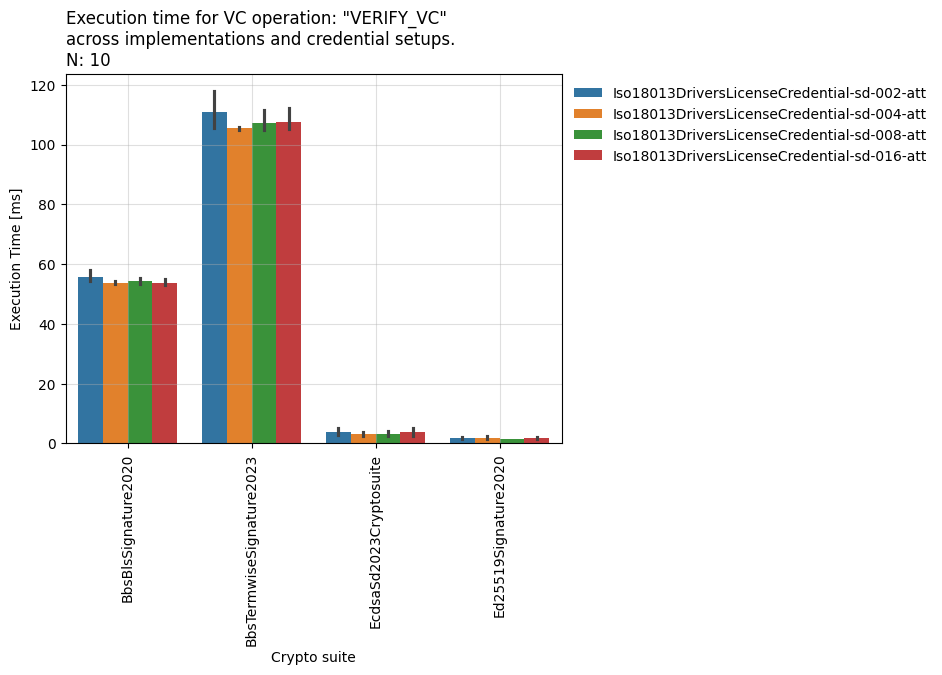

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


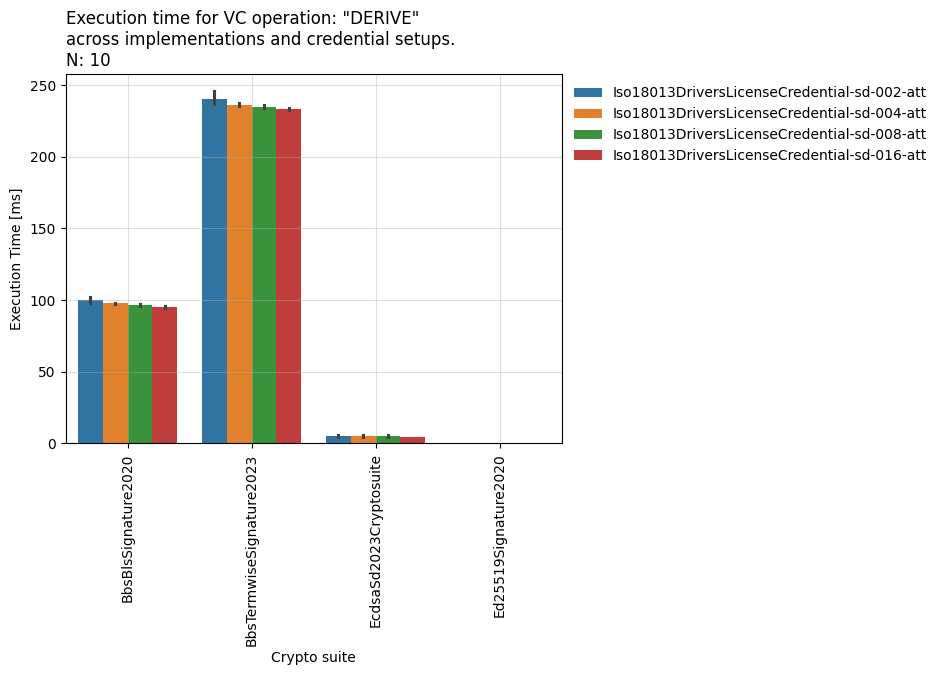

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


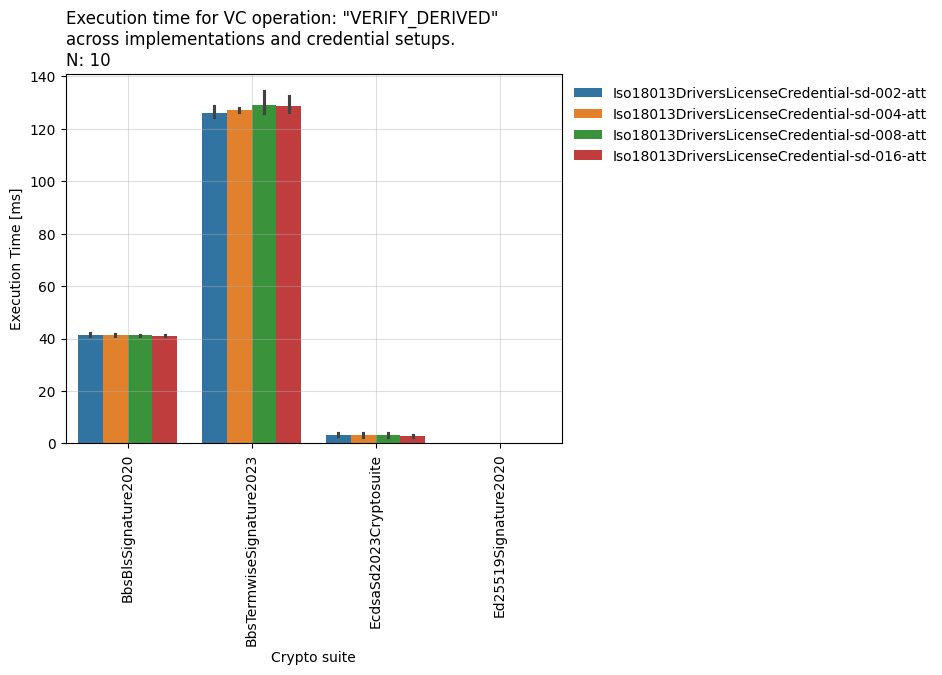

In [18]:
for step_i in STEPS:
    dfsb_step_i = dfsb[dfsb.step == step_i]
    ax = sns.barplot(
            data = dfsb_step_i,
            x = 'implementation',
            y = 'delta',
            hue = 'credentialSetupKey',
            order=implementation_order
        )
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time for VC operation: "{step_i}" \nacross implementations and credential setups.\nN: {N}''',loc='left')
    ax.set_xlabel('Crypto suite')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

---

In [19]:
dfsb_step_i

,implementation,credentialSetupKey,iteration,step,delta
2,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,VERIFY_DERIVED,43.968708
6,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,1,VERIFY_DERIVED,42.781209
10,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,2,VERIFY_DERIVED,40.866500
14,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,3,VERIFY_DERIVED,41.292667
18,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,4,VERIFY_DERIVED,41.315708
...,...,...,...,...,...
462,EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,5,VERIFY_DERIVED,3.239917
466,EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,6,VERIFY_DERIVED,2.370458
470,EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,7,VERIFY_DERIVED,3.261458
474,EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,8,VERIFY_DERIVED,2.490375


/Users/gertjandm/miniforge3/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)
/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/2340493643.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


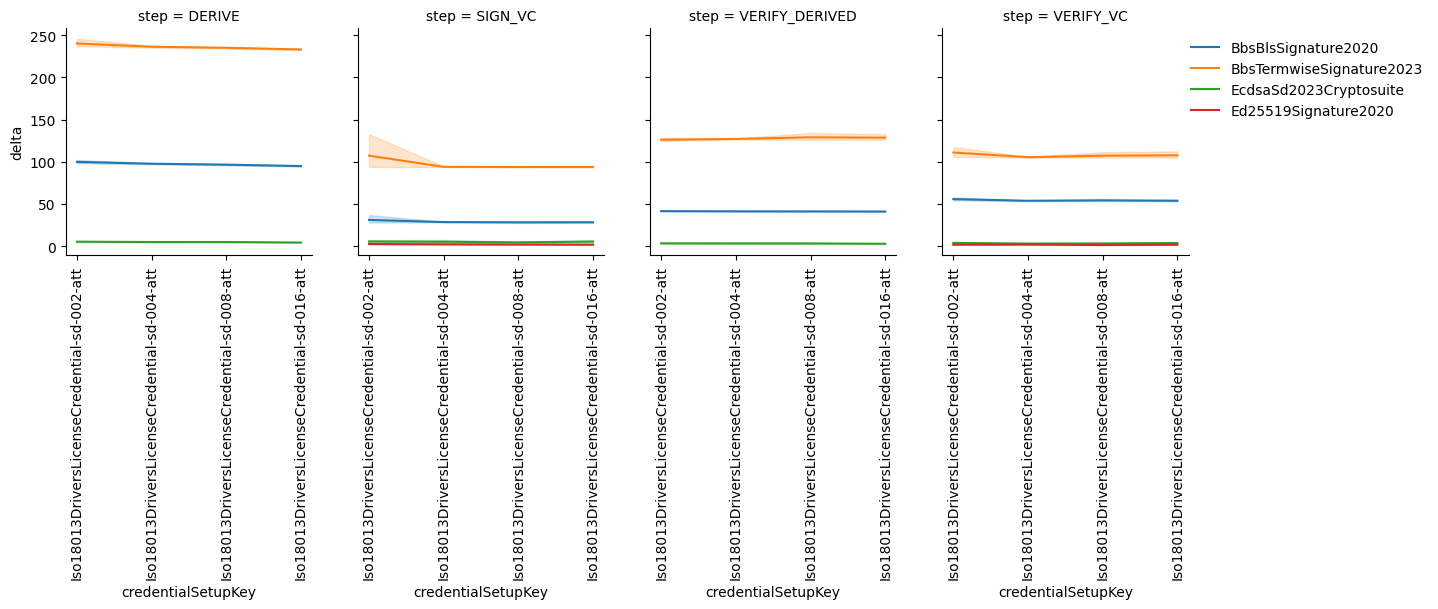

In [20]:
g = sns.FacetGrid(dfsb, col='step', row_order=STEPS, sharey=True)
g.map_dataframe(sns.lineplot,
    x = 'credentialSetupKey',
    y = 'delta',
    hue = 'implementation')
for ax in g.axes.ravel():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend(frameon=False, bbox_to_anchor=(2,1))


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_21105/415337001.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


[Text(0, 0, 'Iso18013DriversLicenseCredential-sd-002-att'),
 Text(1, 0, 'Iso18013DriversLicenseCredential-sd-004-att'),
 Text(2, 0, 'Iso18013DriversLicenseCredential-sd-008-att'),
 Text(3, 0, 'Iso18013DriversLicenseCredential-sd-016-att')]

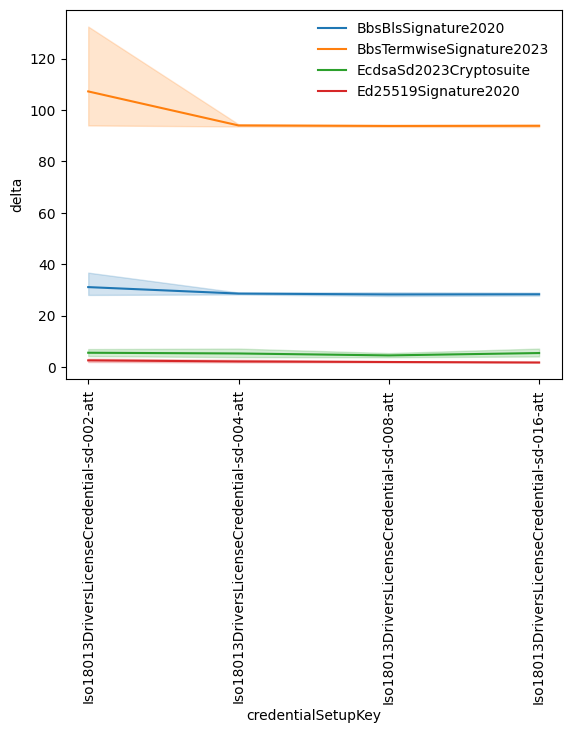

In [21]:
step_i = 'SIGN_VC'
dfsb_step_i = dfsb[dfsb.step == step_i]
ax = sns.lineplot(
        data = dfsb_step_i,
        x = 'credentialSetupKey',
        y = 'delta',
        hue = 'implementation',
        #order=implementation_order
    )
ax.legend(frameon=False, bbox_to_anchor=(1,1))
#ax.set_title(f'''Execution time for VC operation: "{step_i}" \nacross implementations and credential setups.\nN: {N}''',loc='left')
#ax.set_xlabel('Crypto suite')
#ax.set_ylabel('Execution Time [ms]')
#ax.grid(alpha=.4)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#plt.show()

---

In [22]:
df_mean

implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  31.10   
VERIFY_VC                                                55.75   
DERIVE                                                   99.86   
VERIFY_DERIVED                                           41.55   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  28.59   
VERIFY_VC                                                53.80   
DERIVE                                                   97.69   
VERIFY_DERIVED                                           41.28   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  28.25   
VERIFY_VC                                                54.30   
DERIVE                                                   96.59   
VERIFY_DERIVED                                           41.21   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  28.31   
VERIFY_VC                                                53.83   
DERIVE                                                   94.92   
VERIFY_DERIVED                                           41.08   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                 107.23   
VERIFY_VC                                               111.00   
DERIVE                                                  240.16   
VERIFY_DERIVED                                          126.08   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  94.00   
VERIFY_VC                                               105.44   
DERIVE                                                  236.27   
VERIFY_DERIVED                                          127.04   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  93.80   
VERIFY_VC                                               107.24   
DERIVE                                                  235.02   
VERIFY_DERIVED                                          129.01   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  93.85   
VERIFY_VC                                               107.67   
DERIVE                                                  233.11   
VERIFY_DERIVED                                          128.58   

implementation                          EcdsaSd2023Cryptosuite  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                   5.57   
VERIFY_VC                       

In [23]:
df_mean.to_clipboard(excel=True)

Relative performance

In [24]:
# df: relative performance
df_rel = df_mean.copy()
# relative to col
rel2c = 'EcdsaSd2023Cryptosuite'
print('df_rel.shape: ', df_rel.shape)
display(df_rel)

df_rel.shape:  (4, 16)


implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  31.10   
VERIFY_VC                                                55.75   
DERIVE                                                   99.86   
VERIFY_DERIVED                                           41.55   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  28.59   
VERIFY_VC                                                53.80   
DERIVE                                                   97.69   
VERIFY_DERIVED                                           41.28   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  28.25   
VERIFY_VC                                                54.30   
DERIVE                                                   96.59   
VERIFY_DERIVED                                           41.21   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  28.31   
VERIFY_VC                                                53.83   
DERIVE                                                   94.92   
VERIFY_DERIVED                                           41.08   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                 107.23   
VERIFY_VC                                               111.00   
DERIVE                                                  240.16   
VERIFY_DERIVED                                          126.08   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  94.00   
VERIFY_VC                                               105.44   
DERIVE                                                  236.27   
VERIFY_DERIVED                                          127.04   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  93.80   
VERIFY_VC                                               107.24   
DERIVE                                                  235.02   
VERIFY_DERIVED                                          129.01   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  93.85   
VERIFY_VC                                               107.67   
DERIVE                                                  233.11   
VERIFY_DERIVED                                          128.58   

implementation                          EcdsaSd2023Cryptosuite  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                   5.57   
VERIFY_VC                       

In [25]:
print(f'Mean deltas will be computed relative to {rel2c}')
A = df_rel.values
B = df_rel.loc(axis=1)[:,rel2c].values
print('A.shape: ', A.shape)
print('B.shape: ', B.shape)

df_rel_result = pd.DataFrame(
    data=A/B,
    index=df_rel.index,
    columns=df_rel.columns
)
df_rel_result = df_rel_result.round(2)
display(df_rel_result)
df_rel_result.to_clipboard()

Mean deltas will be computed relative to EcdsaSd2023Cryptosuite


KeyError: 'EcdsaSd2023Cryptosuite'

In [ ]:
!